# Lead Scoring Modeling

## Objective
The goal of this notebook is to build and evaluate machine learning models that predict lead conversion probability.

## Modeling Strategy
We will follow a structured approach:

- define features and target
- split the data into training and test sets
- apply appropriate preprocessing
- train a baseline model
- evaluate performance using business-relevant metrics

## Modeling Principle
The objective is not only to maximize predictive performance, but also to build a reliable and interpretable scoring system that can be used in a real-world business setting.

 ## Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

## Data Loading

In [4]:
df = pd.read_csv("/Users/omarpiro/ML_DL_Projects/AI_LEAD_SCORE/data/raw/bank+marketing/bank/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Target Variable Definition

In [10]:
df["target"] = df["y"].map({"no": 0, "yes": 1})
df[["y", "target"]].head()

,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


The original target variable y indicates whether the lead converted.

For modeling purposes, it is transformed into a binary numerical target:
	•	0 → no conversion
	•	1 → conversion

This target will be used to estimate the probability that a lead converts.

## Feature Selection & Data Leakage Handling

In [6]:
drop_cols = ["y", "target", "duration"]

X = df.drop(columns=drop_cols)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 15)
y shape: (45211,)


At this stage, the feature duration is excluded from modeling.

Although it is highly predictive, it is only known after the interaction has occurred. Using it in a lead scoring system designed for pre-contact prioritization would introduce data leakage.

👉 To keep the model realistic and business-usable, we focus on features available before or independently of the final interaction outcome.

## Feature Type Identification

In [7]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


## Categorical Feature Encoding Strategy

In [8]:
ordinal_cols = ["education"]
ordinal_categories = [["unknown", "primary", "secondary", "tertiary"]]

nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)

Ordinal columns: ['education']
Nominal columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Preprocessor

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Ordinal categorical preprocessing
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories))
])

# Nominal categorical preprocessing
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("ord", ordinal_transformer, ordinal_cols),
        ("nom", nominal_transformer, nominal_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### Preprocessing Pipeline

To ensure a robust and reproducible modeling process, we apply different preprocessing strategies based on feature types:

- Numerical features are imputed and scaled  
- Ordinal categorical features are encoded while preserving their natural order  
- Nominal categorical features are one-hot encoded to avoid introducing artificial relationships  

👉 This structured preprocessing ensures that the model receives clean and meaningful inputs.

## Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36168, 15)
Test shape: (9043, 15)


The dataset is split into training and test sets:

- 80% for training
- 20% for evaluation

Stratification is applied to preserve the original class distribution.

👉 This is especially important due to the strong class imbalance in the dataset.

## Model definition

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 1) Baseline: Logistic Regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# 2) Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# 3) Gradient Boosting
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# 4) XGBoost
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric="logloss"
    ))
])

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

list(models.keys())

['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

We evaluate a small and meaningful set of models:

- Logistic Regression as an interpretable baseline  
- Random Forest as a robust ensemble model  
- Gradient Boosting as a strong boosting-based learner  
- XGBoost as a high-performance model for structured tabular data  

👉 This shortlist provides a good balance between interpretability, robustness, and predictive power.

In [14]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.894283,0.659375,0.199433,0.306241,0.801306
3,XGBoost,0.832688,0.370518,0.615312,0.462522,0.798344
1,Random Forest,0.893066,0.634218,0.203214,0.307802,0.788643
0,Logistic Regression,0.755612,0.268302,0.630435,0.376411,0.771838


## Model Evaluation Summary

The comparison of models highlights important trade-offs:

- Gradient Boosting achieves the highest ROC-AUC but suffers from very low recall  
- Logistic Regression captures many conversions but with low precision  
- Random Forest shows moderate performance across all metrics  

👉 XGBoost provides the best overall balance between precision, recall, and ROC-AUC.

## Key Insight

This is not a pure classification problem but a lead prioritization task.

👉 The objective is to identify high-potential leads rather than perfectly classify all observations.

## Model Selection

XGBoost is selected as the best candidate model due to:

- strong ranking capability (high ROC-AUC)  
- good recall (captures a large portion of converting leads)  
- balanced overall performance  

👉 This makes it well-suited for building a lead scoring system.

## Business metrics

In [15]:
best_model = models["XGBoost"]

In [16]:
y_scores = best_model.predict_proba(X_test)[:, 1]

In [18]:
results_analysis = pd.DataFrame({
    "y_true": y_test,
    "score": y_scores
})

results_analysis = results_analysis.sort_values(by="score", ascending=False)
results_analysis.head(30)

,y_true,score
43122,1,0.990227
43579,1,0.986984
43135,0,0.986804
45098,0,0.986613
44016,1,0.986360
41241,1,0.985136
45126,1,0.984838
42322,1,0.984380
42753,0,0.982301
43005,1,0.982156


In [19]:
def precision_at_k(df, k):
    top_k = int(len(df) * k)
    return df.iloc[:top_k]["y_true"].mean()

for k in [0.1, 0.2, 0.3]:
    print(f"Precision@{int(k*100)}%:", precision_at_k(results_analysis, k))

Precision@10%: 0.5210176991150443
Precision@20%: 0.36172566371681414
Precision@30%: 0.2783923303834808


In [22]:
baseline_rate = y_test.mean()
print("Baseline conversion rate:", baseline_rate)

Baseline conversion rate: 0.11699657193409267


### Business-Oriented Evaluation

To evaluate the model from a business perspective, we analyze how well it ranks leads.

Instead of focusing only on classification metrics, we measure performance on the top-ranked leads.

### Precision@K

- Top 10% leads show a significantly higher conversion rate compared to the baseline  
- Top 20% and 30% also outperform the average conversion rate  

### Business Impact

The baseline conversion rate is relatively low (~12%).

However, by targeting only the highest-scoring leads:

- Conversion rates increase substantially  
- Sales efforts can be focused on high-value prospects  

👉 This demonstrates the practical value of the model in a real-world lead scoring system.

## Key Takeaway

The model is effective at ranking leads by conversion probability.

👉 This makes it highly suitable for prioritization and resource allocation in sales workflows.

In [20]:
import numpy as np

# Trier par score
df_gain = results_analysis.copy()

# Total positives
total_positives = df_gain["y_true"].sum()

# Cumul des conversions
df_gain["cum_conversions"] = df_gain["y_true"].cumsum()

# % de leads
df_gain["perc_leads"] = np.arange(1, len(df_gain)+1) / len(df_gain)

# % de conversions capturées
df_gain["perc_conversions"] = df_gain["cum_conversions"] / total_positives

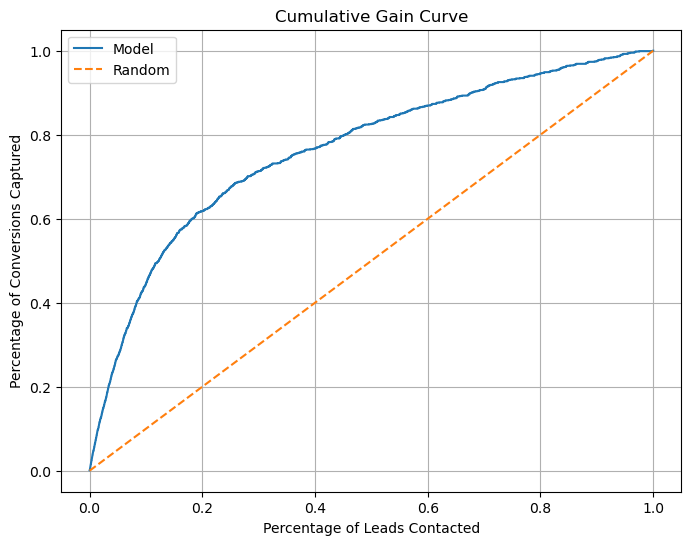

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Modèle
plt.plot(df_gain["perc_leads"], df_gain["perc_conversions"], label="Model")

# Random baseline
plt.plot([0,1], [0,1], linestyle="--", label="Random")

plt.xlabel("Percentage of Leads Contacted")
plt.ylabel("Percentage of Conversions Captured")
plt.title("Cumulative Gain Curve")
plt.legend()
plt.grid()

plt.show()

### Business Impact Analysis

The model demonstrates strong performance when evaluated from a business perspective.

### Precision@K Results

- Top 10% leads: ~52% conversion rate  
- Top 20% leads: ~36% conversion rate  
- Top 30% leads: ~28% conversion rate  

### Baseline Comparison

The overall conversion rate in the dataset is approximately 12%.

👉 By targeting only the top-ranked leads, the model increases conversion rates by up to 4x.

### Business Implications

- Sales teams can focus on a smaller subset of high-value leads  
- Marketing efforts become significantly more efficient  
- Customer acquisition cost can be reduced  

👉 This demonstrates the practical value of the model in a real-world lead scoring system.

## Final Takeaway

The model is not only predictive but also highly effective for prioritization.

👉 It enables data-driven decision making in lead management workflows.